# Wave Packet Ray Tracing in Cartesian Shearing Box

## Physical Setup

- **Constant shear rate**: $\sigma_s$ (background shear)
- **Coriolis parameter**: $f$ 
- **Brunt-Väisälä frequency**: $N$ (stratification)
- **Effective vorticity**: $F = f(\sigma_s + f)$

## Simplified Dispersion Relation $k_x << k_y$

$$
k_y^2 + \frac{(\Phi^2 + F) k_z^2}{\Phi^2 + N^2} = 0
$$

where $\Phi = -i(\omega + k_x \sigma_s y)$ and $\omega$ is the real frequency.

## Key Insight

With $k_x$ and $k_z$ **fixed**, the dispersion relation gives:

$$
\frac{k_y^2}{k_z^2} = -\frac{\Phi^2 + F}{\Phi^2 + N^2}
$$

For quasi-stationary waves ($\omega \approx 0$): $\Phi \approx -ik_x\sigma_s y$ (purely imaginary), so $\Phi^2 \approx -(k_x\sigma_s y)^2 < 0$

## Evanescent Region

Waves are evanescent (non-propagating) when $k_y^2 < 0$, which occurs when:

$$
-\frac{\Phi^2 + F}{\Phi^2 + N^2} < 0
$$

For $F > 0$, this gives an evanescent region: $|y| < \sqrt{F}/|k_x\sigma_s|$

## Ray Trajectory

The group velocity $\mathbf{C}_g \perp \mathbf{k}$ gives:

$$
\frac{dz}{dy} = \pm\frac{k_y}{k_z}
$$

Since $k_z$ is fixed (non-zero), we integrate along $y$ to avoid singularities when $k_y \to 0$.

**Two modes** correspond to the **two signs** of $dz/dy$:
- **Mode 1**: $dz/dy = +k_y/k_z$ 
- **Mode 2**: $dz/dy = -k_y/k_z$

For each mode, we integrate in both $\pm y$ directions from the starting point to obtain the **complete trajectory**.

Critical layers at $y_c = \pm N/(|k_x\sigma_s|)$ are approached but never reached.

## 1. Dispersion Relation and Ray Equations

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
class CartesianShearingBoxRays:
    """
    Ray tracing for inertia-gravity waves in shearing box.
    
    Fixed: kx, kz
    Variable: ky(y), determined by dispersion relation
    """
    
    def __init__(self, N, f, sigma_s, kx, Lx, omega=0.0):
        """
        Parameters:
        -----------
        N : float
            Brunt-Väisälä frequency
        f : float
            Coriolis parameter
        sigma_s : float
            Shear rate (negative for cyclonic)
        kx : float
            Fixed streamwise wavenumber
        Lx : float
            Domain size for normalization
        omega : float, optional
            Wave frequency (default: 0.0 for quasi-stationary waves)
        """
        self.N = N
        self.f = f
        self.sigma_s = sigma_s
        self.F = f * (sigma_s + f)
        self.kx = kx
        self.Lx = Lx
        self.omega = omega
        
        print(f"Shearing Box Ray Tracer Initialized:")
        print(f"  N = {N}, f = {f}, σ_s = {sigma_s}")
        print(f"  F = f(σ_s + f) = {self.F}")
        print(f"  kx = {kx} (fixed)")
        
        # Calculate critical layer location (where omega = 0)
        if kx != 0:
            self.y_crit = N / (abs(kx * sigma_s))
            print(f"  Critical layers at y = ±{self.y_crit:.4f}")
        else:
            self.y_crit = np.inf
        
        # Calculate evanescent region boundaries
        # For quasi-stationary waves (omega ~ 0), ky^2 < 0 when:
        # -(Phi^2 + F)/(Phi^2 + N^2) < 0
        # This occurs when Phi^2 + F > 0 and Phi^2 + N^2 > 0
        # or when Phi^2 + F < 0 and Phi^2 + N^2 < 0
        # With Phi^2 = -(kx*sigma_s*y)^2, we have Phi^2 < 0
        # So: -(kx*sigma_s*y)^2 + F > 0 requires F > 0 (not our case)
        # And: -(kx*sigma_s*y)^2 + F < 0 AND -(kx*sigma_s*y)^2 + N^2 < 0
        # The second gives: (kx*sigma_s*y)^2 > N^2, i.e., |y| > N/|kx*sigma_s|
        # The first gives: (kx*sigma_s*y)^2 > F, i.e., |y| > sqrt(F)/|kx*sigma_s|
        
        if self.F > 0 and kx != 0:
            self.y_evan_limit = np.sqrt(self.F) / abs(kx * sigma_s)
            print(f"  Evanescent region for |y| < {self.y_evan_limit:.4f}")
        else:
            self.y_evan_limit = 0.0
            print(f"  No evanescent region (F = {self.F} <= 0)")
    
    def compute_ky(self, y, kz):
        """
        Compute ky from dispersion relation at position y.
        
        From: ky^2/kz^2 = -(Phi^2 + F)/(Phi^2 + N^2)
        where Phi = -i*(omega + kx*sigma_s*y)
        
        For omega = 0 (quasi-stationary):
        Phi ≈ -i*kx*sigma_s*y, so Phi^2 ≈ -(kx*sigma_s*y)^2
        
        Returns:
        --------
        ky : float or None
            Magnitude of ky (positive). Returns None if evanescent.
        """
        # General form: Phi^2 = -(omega + kx*sigma_s*y)^2
        Phi_squared = -(self.omega + self.kx * self.sigma_s * y)**2
        
        # ky^2/kz^2 = -(Phi^2 + F)/(Phi^2 + N^2)
        numerator = Phi_squared + self.F
        denominator = Phi_squared + self.N**2
        
        if abs(denominator) < 1e-10:
            return None  # Singular point
        
        ratio = -numerator / denominator
        
        if ratio < 0:
            return None  # Evanescent (ky imaginary)
        
        # Return magnitude only
        ky_mag = np.sqrt(ratio) * abs(kz)
        
        return ky_mag
    
    def compute_dzdy(self, y, kz, sign_choice=+1):
        """
        Compute dz/dy from group velocity perpendicular to wavevector.
        
        Since C_g ⊥ k, we have: dz/dy = ±ky/kz
        
        Parameters:
        -----------
        y : float
            Current y position
        kz : float
            Fixed vertical wavenumber
        sign_choice : +1 or -1
            Choose which branch: +ky/kz or -ky/kz
        
        This avoids division by zero when ky → 0.
        """
        ky = self.compute_ky(y, kz)
        
        if ky is None:
            return None  # Evanescent region
        
        return sign_choice * ky / kz
    
    def trace_ray(self, y0, z0, kz, sign_choice=+1, dy=0.01, max_steps=10000):
        """
        Trace complete ray trajectory by integrating in both directions from (y0, z0).
        
        Parameters:
        -----------
        y0, z0 : float
            Starting position
        kz : float
            Fixed vertical wavenumber
        sign_choice : +1 or -1
            Choose branch: +ky/kz or -ky/kz
        dy : float
            Integration step in y
        max_steps : int
            Maximum number of steps in each direction
            
        Returns:
        --------
        y_array, z_array : arrays
            Complete ray trajectory (both directions from starting point)
        """
        # Integrate in positive y direction
        y_pos_list = [y0]
        z_pos_list = [z0]
        y_current = y0
        z_current = z0
        
        for step in range(max_steps):
            dzdy = self.compute_dzdy(y_current, kz, sign_choice)
            
            if dzdy is None:
                break  # Hit evanescent region
            
            # Check boundaries
            if abs(y_current) > 0.995 * self.y_crit:
                break  # Near critical layer
            
            # Step in +y direction
            y_current += dy
            z_current += dzdy * dy
            
            y_pos_list.append(y_current)
            z_pos_list.append(z_current)
            
            if abs(y_current) > self.Lx or abs(z_current) > self.Lx:
                break
        
        # Integrate in negative y direction
        y_neg_list = []
        z_neg_list = []
        y_current = y0
        z_current = z0
        
        for step in range(max_steps):
            dzdy = self.compute_dzdy(y_current, kz, sign_choice)
            
            if dzdy is None:
                break  # Hit evanescent region
            
            # Check boundaries
            if abs(y_current) > 0.995 * self.y_crit:
                break  # Near critical layer
            
            # Step in -y direction
            y_current -= dy
            z_current -= dzdy * dy
            
            y_neg_list.append(y_current)
            z_neg_list.append(z_current)
            
            if abs(y_current) > self.Lx or abs(z_current) > self.Lx:
                break
        
        # Combine: reverse negative direction, then add positive direction
        y_neg_list.reverse()
        z_neg_list.reverse()
        y_array = np.array(y_neg_list + y_pos_list)
        z_array = np.array(z_neg_list + z_pos_list)        
        
        return y_array, z_array
        

## 2. Background Parameters

In [4]:
# Physical parameters
N = 2.0
f = 1.0
sigma_s = 1.5

## 3. Trace Single Ray (Both Modes)

Shearing Box Ray Tracer Initialized:
  N = 2.0, f = 1.0, σ_s = 1.5
  F = f(σ_s + f) = 2.5
  kx = 0.6283185307179586 (fixed)
  Critical layers at y = ±2.1221
  Evanescent region for |y| < 1.6776
Starting point: y0 = 1.6876 (evanescent limit: 1.6776), z0 = 0.0000
Mode 1 (+ky/kz): 46 points, y ∈ [1.668, 2.118], z ∈ [-0.001, 0.536]
Mode 2 (-ky/kz): 46 points, y ∈ [1.668, 2.118], z ∈ [-0.536, 0.001]


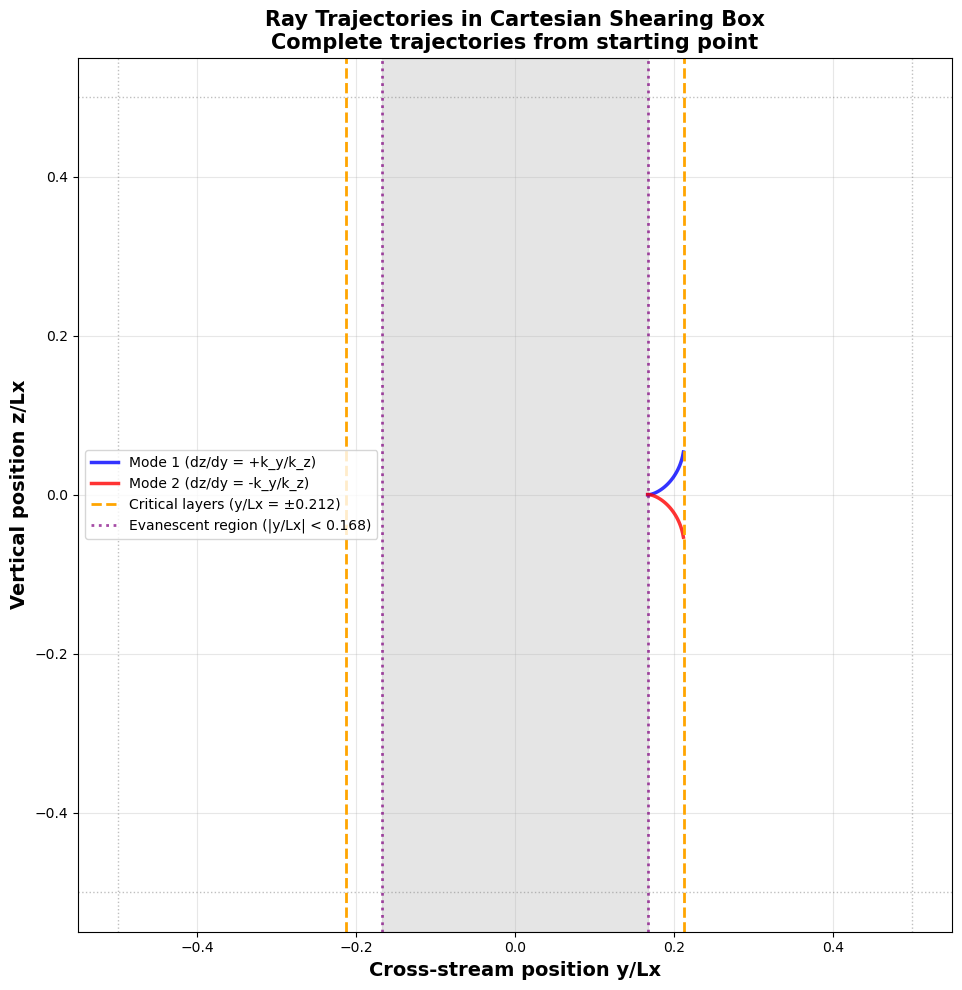

In [5]:
# Set parameters and construct tracer
Lx = 10.0
nx = 1.0
kx = 2 * np.pi * nx / Lx
nz = 1.0
kz = 2 * np.pi * nz / Lx
tracer = CartesianShearingBoxRays(N, f, sigma_s, kx, Lx)

# Starting point - just outside evanescent region at z = 0
if tracer.y_evan_limit > 0:
    y0 = tracer.y_evan_limit + 0.01  # Start just outside evanescent boundary
else:
    y0 = 0.01  # No evanescent region, start near origin
z0 = 0.0

print(f"Starting point: y0 = {y0:.4f} (evanescent limit: {tracer.y_evan_limit:.4f}), z0 = {z0:.4f}")

# Mode 1: dz/dy = +ky/kz
y1, z1 = tracer.trace_ray(y0, z0, kz=kz, sign_choice=+1, dy=0.01)

# Mode 2: dz/dy = -ky/kz
y2, z2 = tracer.trace_ray(y0, z0, kz=kz, sign_choice=-1, dy=0.01)

print(f"Mode 1 (+ky/kz): {len(z1)} points, y ∈ [{y1.min():.3f}, {y1.max():.3f}], z ∈ [{z1.min():.3f}, {z1.max():.3f}]")
print(f"Mode 2 (-ky/kz): {len(z2)} points, y ∈ [{y2.min():.3f}, {y2.max():.3f}], z ∈ [{z2.min():.3f}, {z2.max():.3f}]")

fig, ax = plt.subplots(figsize=(10, 10))

# Plot trajectories (normalized)
ax.plot(y1/Lx, z1/Lx, 'b-', linewidth=2.5, label='Mode 1 (dz/dy = +k_y/k_z)', alpha=0.8)
ax.plot(y2/Lx, z2/Lx, 'r-', linewidth=2.5, label='Mode 2 (dz/dy = -k_y/k_z)', alpha=0.8)

# Critical layers
y_c = tracer.y_crit
ax.axvline(y_c/Lx, color='orange', linestyle='--', linewidth=2, 
           label=f'Critical layers (y/Lx = ±{y_c/Lx:.3f})')
ax.axvline(-y_c/Lx, color='orange', linestyle='--', linewidth=2)

# Evanescent region (if exists)
if tracer.y_evan_limit > 0:
    y_ev = tracer.y_evan_limit
    ax.axvline(y_ev/Lx, color='purple', linestyle=':', linewidth=2, alpha=0.7,
               label=f'Evanescent region (|y/Lx| < {y_ev/Lx:.3f})')
    ax.axvline(-y_ev/Lx, color='purple', linestyle=':', linewidth=2, alpha=0.7)
    ax.axvspan(-y_ev/Lx, y_ev/Lx, color='gray', alpha=0.2, zorder=0)

# Domain boundaries
ax.axvline(-0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax.axvline(0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax.axhline(-0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5)

# Formatting
ax.set_xlabel('Cross-stream position y/Lx', fontsize=14, fontweight='bold')
ax.set_ylabel('Vertical position z/Lx', fontsize=14, fontweight='bold')
ax.set_title('Ray Trajectories in Cartesian Shearing Box\n'
             'Complete trajectories from starting point', 
             fontsize=15, fontweight='bold')
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
ax.set_xlim(-0.55, 0.55)
ax.set_ylim(-0.55, 0.55)

plt.tight_layout()
plt.show()

## 4. St. Andrew's Cross Pattern

Trace multiple rays with different streamwise wavenumbers $n_x$. Each $n_x$ produces different critical layer locations and trajectory shapes. Both modes (both signs of $dz/dy$) are shown for each $n_x$.

Shearing Box Ray Tracer Initialized:
  N = 2.0, f = 1.0, σ_s = 1.5
  F = f(σ_s + f) = 2.5
  kx = 0.6283185307179586 (fixed)
  Critical layers at y = ±2.1221
  Evanescent region for |y| < 1.6776
nx = 1: y_crit = 2.1221, y_evan = 1.6776, Mode 1 has 46 points, Mode 2 has 46 points
Shearing Box Ray Tracer Initialized:
  N = 2.0, f = 1.0, σ_s = 1.5
  F = f(σ_s + f) = 2.5
  kx = 1.2566370614359172 (fixed)
  Critical layers at y = ±1.0610
  Evanescent region for |y| < 0.8388
nx = 2: y_crit = 1.0610, y_evan = 0.8388, Mode 1 has 24 points, Mode 2 has 24 points
Shearing Box Ray Tracer Initialized:
  N = 2.0, f = 1.0, σ_s = 1.5
  F = f(σ_s + f) = 2.5
  kx = 1.8849555921538759 (fixed)
  Critical layers at y = ±0.7074
  Evanescent region for |y| < 0.5592
nx = 3: y_crit = 0.7074, y_evan = 0.5592, Mode 1 has 17 points, Mode 2 has 17 points
Shearing Box Ray Tracer Initialized:
  N = 2.0, f = 1.0, σ_s = 1.5
  F = f(σ_s + f) = 2.5
  kx = 2.5132741228718345 (fixed)
  Critical layers at y = ±0.5305
  Evan

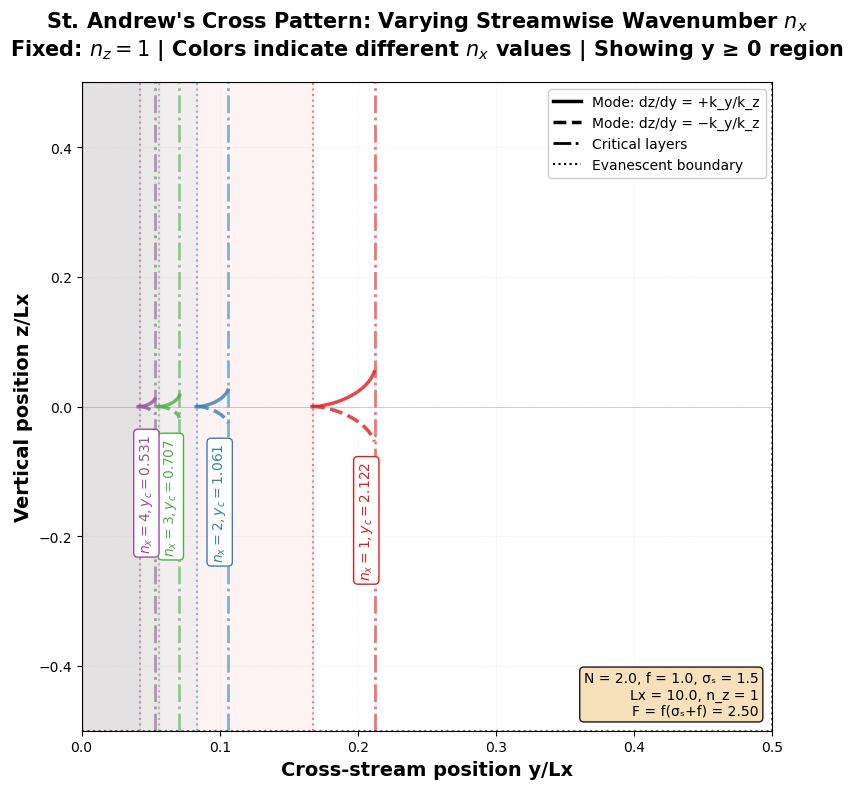

In [6]:
# Physical parameters
N = 2.0
f = 1.0
sigma_s = 1.5

# Different nx values (integer wave indices), fixed nz = 1
Lx = 10.0
nx_values = [1, 2, 3, 4]
nz_fixed = 1

trajectories_pos = []  # dz/dy = +ky/kz
trajectories_neg = []  # dz/dy = -ky/kz
critical_layers = []   # Critical layer positions for each nx
evanescent_limits = [] # Evanescent region limits for each nx
starting_points = []   # Starting points for each nx

for nx in nx_values:
    kx_val = 2 * np.pi * nx / Lx
    kz_val = 2 * np.pi * nz_fixed / Lx
    
    # Create temporary tracer for this nx
    temp_tracer = CartesianShearingBoxRays(N, f, sigma_s, kx_val, Lx)
    
    # Starting point - just outside evanescent region at z = 0
    if temp_tracer.y_evan_limit > 0:
        y_start = temp_tracer.y_evan_limit + 0.01
    else:
        y_start = 0.01
    z_start = 0.0
    
    # Mode 1: dz/dy = +ky/kz
    y_pos, z_pos = temp_tracer.trace_ray(y_start, z_start, kz=kz_val, sign_choice=+1, dy=0.01)
    trajectories_pos.append({'y': y_pos, 'z': z_pos, 'nx': nx})
    
    # Mode 2: dz/dy = -ky/kz
    y_neg, z_neg = temp_tracer.trace_ray(y_start, z_start, kz=kz_val, sign_choice=-1, dy=0.01)
    trajectories_neg.append({'y': y_neg, 'z': z_neg, 'nx': nx})
    
    # Store critical layers, evanescent limits, and starting points
    critical_layers.append(temp_tracer.y_crit)
    evanescent_limits.append(temp_tracer.y_evan_limit)
    starting_points.append((y_start, z_start))
    
    print(f"nx = {nx}: y_crit = {temp_tracer.y_crit:.4f}, y_evan = {temp_tracer.y_evan_limit:.4f}, "
          f"Mode 1 has {len(z_pos)} points, Mode 2 has {len(z_neg)} points")
    
fig, ax = plt.subplots(figsize=(8, 8))

colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']

# Plot trajectories for each nx
for i, (traj_pos, traj_neg) in enumerate(zip(trajectories_pos, trajectories_neg)):
    nx_val = traj_pos['nx']
    color = colors[i]
    
    # Mode 1: solid line
    ax.plot(traj_pos['y']/Lx, traj_pos['z']/Lx, color=color, linestyle='-', 
            linewidth=2.5, alpha=0.8)
    
    # Mode 2: dashed line
    ax.plot(traj_neg['y']/Lx, traj_neg['z']/Lx, color=color, linestyle='--', 
            linewidth=2.5, alpha=0.8)
    
    # Critical layers with same color (only positive side for cleaner plot)
    y_c = critical_layers[i]
    ax.axvline(y_c/Lx, color=color, linestyle='-.', linewidth=2, alpha=0.6, zorder=1)
    
    # Add text label near critical layer with nx and yc value
    ax.text(y_c/Lx, np.min(traj_neg['z'])/Lx-0.03, f'$n_x={nx_val}, y_c={y_c:.3f}$', fontsize=10, 
            color=color, fontweight='bold', rotation=90, 
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color, alpha=1.0))
    
    # Evanescent region boundaries with same color (only positive side)
    if evanescent_limits[i] > 0:
        y_ev = evanescent_limits[i]
        ax.axvline(y_ev/Lx, color=color, linestyle=':', linewidth=1.5, alpha=0.5, zorder=1)
        # Light shading for evanescent region
        ax.axvspan(0, y_ev/Lx, color=color, alpha=0.05, zorder=0)

# Domain boundaries
ax.axvline(0.5, color='black', linestyle=':', linewidth=1.5, alpha=0.6)
ax.axhline(-0.5, color='black', linestyle=':', linewidth=1.5, alpha=0.6)
ax.axhline(0.5, color='black', linestyle=':', linewidth=1.5, alpha=0.6)

# Axis at y=0 (left boundary)
ax.axvline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.8)
ax.axhline(0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)

# Legend - show line styles only (in black)
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='black', linewidth=2.5, linestyle='-', label='Mode: dz/dy = +k_y/k_z'),
    Line2D([0], [0], color='black', linewidth=2.5, linestyle='--', label='Mode: dz/dy = −k_y/k_z'),
    Line2D([0], [0], color='black', linewidth=2, linestyle='-.', label='Critical layers'),
    Line2D([0], [0], color='black', linewidth=1.5, linestyle=':', label='Evanescent boundary')
]
ax.legend(handles=legend_elements, fontsize=10, loc='upper right', framealpha=1.0)

# Formatting
ax.set_xlabel('Cross-stream position y/Lx', fontsize=14, fontweight='bold')
ax.set_ylabel('Vertical position z/Lx', fontsize=14, fontweight='bold')
ax.set_title("St. Andrew's Cross Pattern: Varying Streamwise Wavenumber $n_x$\n"
             f"Fixed: $n_z = {nz_fixed}$ | Colors indicate different $n_x$ values | Showing y ≥ 0 region", fontsize=15, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)
ax.set_xlim( 0.0, 0.5)
ax.set_ylim(-0.5, 0.5)

# Parameter text
param_text = f'N = {N}, f = {f}, σₛ = {sigma_s}\nLx = {Lx}, n_z = {nz_fixed}\nF = f(σₛ+f) = {tracer.F:.2f}'
ax.text(0.98, 0.02, param_text, transform=ax.transAxes, 
        fontsize=10, verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9))

plt.tight_layout()
plt.show()

Shearing Box Ray Tracer Initialized:
  N = 1.5, f = 1.0, σ_s = -0.9
  F = f(σ_s + f) = 0.09999999999999998
  kx = 0.6283185307179586 (fixed)
  Critical layers at y = ±2.6526
  Evanescent region for |y| < 0.5592
nx = 1: y_crit = 2.6526, y_evan = 0.5592, Mode 1 has 210 points, Mode 2 has 210 points
Shearing Box Ray Tracer Initialized:
  N = 1.5, f = 1.0, σ_s = -0.9
  F = f(σ_s + f) = 0.09999999999999998
  kx = 1.2566370614359172 (fixed)
  Critical layers at y = ±1.3263
  Evanescent region for |y| < 0.2796
nx = 2: y_crit = 1.3263, y_evan = 0.2796, Mode 1 has 106 points, Mode 2 has 106 points
Shearing Box Ray Tracer Initialized:
  N = 1.5, f = 1.0, σ_s = -0.9
  F = f(σ_s + f) = 0.09999999999999998
  kx = 1.8849555921538759 (fixed)
  Critical layers at y = ±0.8842
  Evanescent region for |y| < 0.1864
nx = 3: y_crit = 0.8842, y_evan = 0.1864, Mode 1 has 71 points, Mode 2 has 71 points
Shearing Box Ray Tracer Initialized:
  N = 1.5, f = 1.0, σ_s = -0.9
  F = f(σ_s + f) = 0.09999999999999998
 

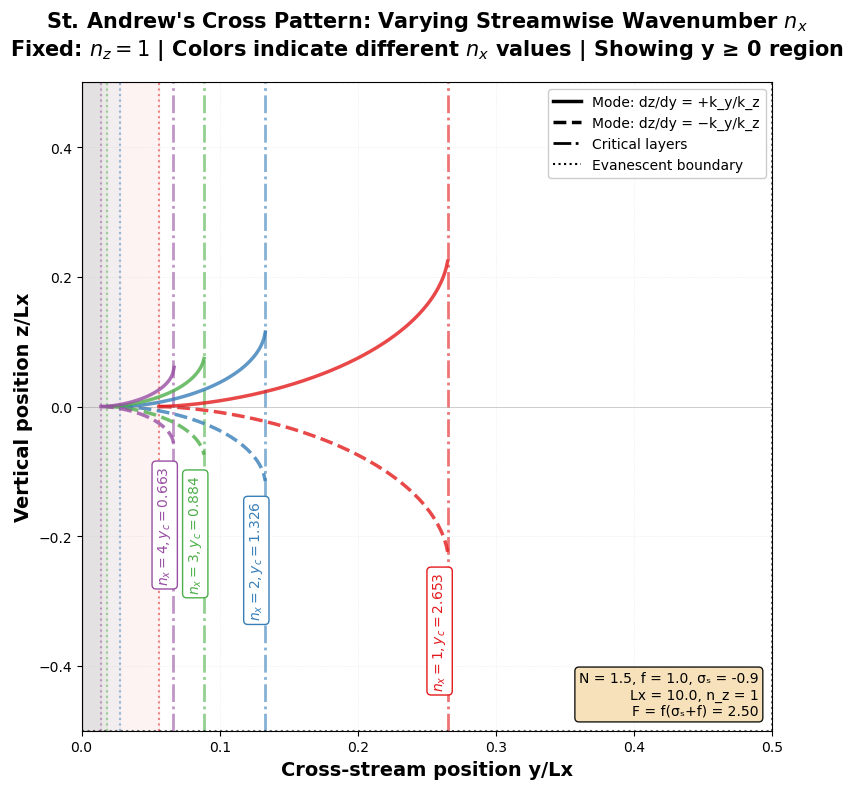

In [7]:
# Physical parameters
N = 1.5
f = 1.0
sigma_s = -0.9

# Different nx values (integer wave indices), fixed nz = 1
Lx = 10.0
nx_values = [1, 2, 3, 4]
nz_fixed = 1

trajectories_pos = []  # dz/dy = +ky/kz
trajectories_neg = []  # dz/dy = -ky/kz
critical_layers = []   # Critical layer positions for each nx
evanescent_limits = [] # Evanescent region limits for each nx
starting_points = []   # Starting points for each nx

for nx in nx_values:
    kx_val = 2 * np.pi * nx / Lx
    kz_val = 2 * np.pi * nz_fixed / Lx
    
    # Create temporary tracer for this nx
    temp_tracer = CartesianShearingBoxRays(N, f, sigma_s, kx_val, Lx)
    
    # Starting point - just outside evanescent region at z = 0
    if temp_tracer.y_evan_limit > 0:
        y_start = temp_tracer.y_evan_limit + 0.01
    else:
        y_start = 0.01
    z_start = 0.0
    
    # Mode 1: dz/dy = +ky/kz
    y_pos, z_pos = temp_tracer.trace_ray(y_start, z_start, kz=kz_val, sign_choice=+1, dy=0.01)
    trajectories_pos.append({'y': y_pos, 'z': z_pos, 'nx': nx})
    
    # Mode 2: dz/dy = -ky/kz
    y_neg, z_neg = temp_tracer.trace_ray(y_start, z_start, kz=kz_val, sign_choice=-1, dy=0.01)
    trajectories_neg.append({'y': y_neg, 'z': z_neg, 'nx': nx})
    
    # Store critical layers, evanescent limits, and starting points
    critical_layers.append(temp_tracer.y_crit)
    evanescent_limits.append(temp_tracer.y_evan_limit)
    starting_points.append((y_start, z_start))
    
    print(f"nx = {nx}: y_crit = {temp_tracer.y_crit:.4f}, y_evan = {temp_tracer.y_evan_limit:.4f}, "
          f"Mode 1 has {len(z_pos)} points, Mode 2 has {len(z_neg)} points")
    
fig, ax = plt.subplots(figsize=(8, 8))

colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']

# Plot trajectories for each nx
for i, (traj_pos, traj_neg) in enumerate(zip(trajectories_pos, trajectories_neg)):
    nx_val = traj_pos['nx']
    color = colors[i]
    
    # Mode 1: solid line
    ax.plot(traj_pos['y']/Lx, traj_pos['z']/Lx, color=color, linestyle='-', 
            linewidth=2.5, alpha=0.8)
    
    # Mode 2: dashed line
    ax.plot(traj_neg['y']/Lx, traj_neg['z']/Lx, color=color, linestyle='--', 
            linewidth=2.5, alpha=0.8)
    
    # Critical layers with same color (only positive side for cleaner plot)
    y_c = critical_layers[i]
    ax.axvline(y_c/Lx, color=color, linestyle='-.', linewidth=2, alpha=0.6, zorder=1)
    
    # Add text label near critical layer with nx and yc value
    ax.text(y_c/Lx, np.min(traj_neg['z'])/Lx-0.03, f'$n_x={nx_val}, y_c={y_c:.3f}$', fontsize=10, 
            color=color, fontweight='bold', rotation=90, 
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color, alpha=1.0))
    
    # Evanescent region boundaries with same color (only positive side)
    if evanescent_limits[i] > 0:
        y_ev = evanescent_limits[i]
        ax.axvline(y_ev/Lx, color=color, linestyle=':', linewidth=1.5, alpha=0.5, zorder=1)
        # Light shading for evanescent region
        ax.axvspan(0, y_ev/Lx, color=color, alpha=0.05, zorder=0)

# Domain boundaries
ax.axvline(0.5, color='black', linestyle=':', linewidth=1.5, alpha=0.6)
ax.axhline(-0.5, color='black', linestyle=':', linewidth=1.5, alpha=0.6)
ax.axhline(0.5, color='black', linestyle=':', linewidth=1.5, alpha=0.6)

# Axis at y=0 (left boundary)
ax.axvline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.8)
ax.axhline(0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)

# Legend - show line styles only (in black)
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='black', linewidth=2.5, linestyle='-', label='Mode: dz/dy = +k_y/k_z'),
    Line2D([0], [0], color='black', linewidth=2.5, linestyle='--', label='Mode: dz/dy = −k_y/k_z'),
    Line2D([0], [0], color='black', linewidth=2, linestyle='-.', label='Critical layers'),
    Line2D([0], [0], color='black', linewidth=1.5, linestyle=':', label='Evanescent boundary')
]
ax.legend(handles=legend_elements, fontsize=10, loc='upper right', framealpha=1.0)

# Formatting
ax.set_xlabel('Cross-stream position y/Lx', fontsize=14, fontweight='bold')
ax.set_ylabel('Vertical position z/Lx', fontsize=14, fontweight='bold')
ax.set_title("St. Andrew's Cross Pattern: Varying Streamwise Wavenumber $n_x$\n"
             f"Fixed: $n_z = {nz_fixed}$ | Colors indicate different $n_x$ values | Showing y ≥ 0 region", fontsize=15, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)
ax.set_xlim( 0.0, 0.5)
ax.set_ylim(-0.5, 0.5)

# Parameter text
param_text = f'N = {N}, f = {f}, σₛ = {sigma_s}\nLx = {Lx}, n_z = {nz_fixed}\nF = f(σₛ+f) = {tracer.F:.2f}'
ax.text(0.98, 0.02, param_text, transform=ax.transAxes, 
        fontsize=10, verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9))

plt.tight_layout()
plt.show()

---

# Part II: Zombie Vortex Instability - Memory-Resetting Ray Tracing

This section implements the frequency-hopping chain reaction model for Cartesian shear flow:

1. Start at $y_0$ with frequency $\omega_0 = -k_x \sigma_s y_0$ (barotropic critical layer condition)
2. Propagate until hitting baroclinic critical layer at $y_i$ where $|\omega_0 - (-k_x \sigma_s y_i)| = N$
3. Energy traps, frequency resets to $\omega_i = -k_x \sigma_s y_i$, next generation begins

## 5. Calculate Zombie Lattice (Cartesian)


ZOMBIE LATTICE CALCULATION (CARTESIAN)
  kx = 0.628319, σs = -1.500000, N = 1.000000
  Frequency spacing: Δy = N/(|kx·σs|) = 1.061033
  Starting at y0 = 0.500000, ω0 = 0.471239

  Total generations: 10
  Generation range: [-5, 4]
  Y range: [-4.8052, 4.7441]
  Y-spacing: mean=1.061033, std=0.00000000
  Frequency jumps: mean=1.000000, target N=1.000000


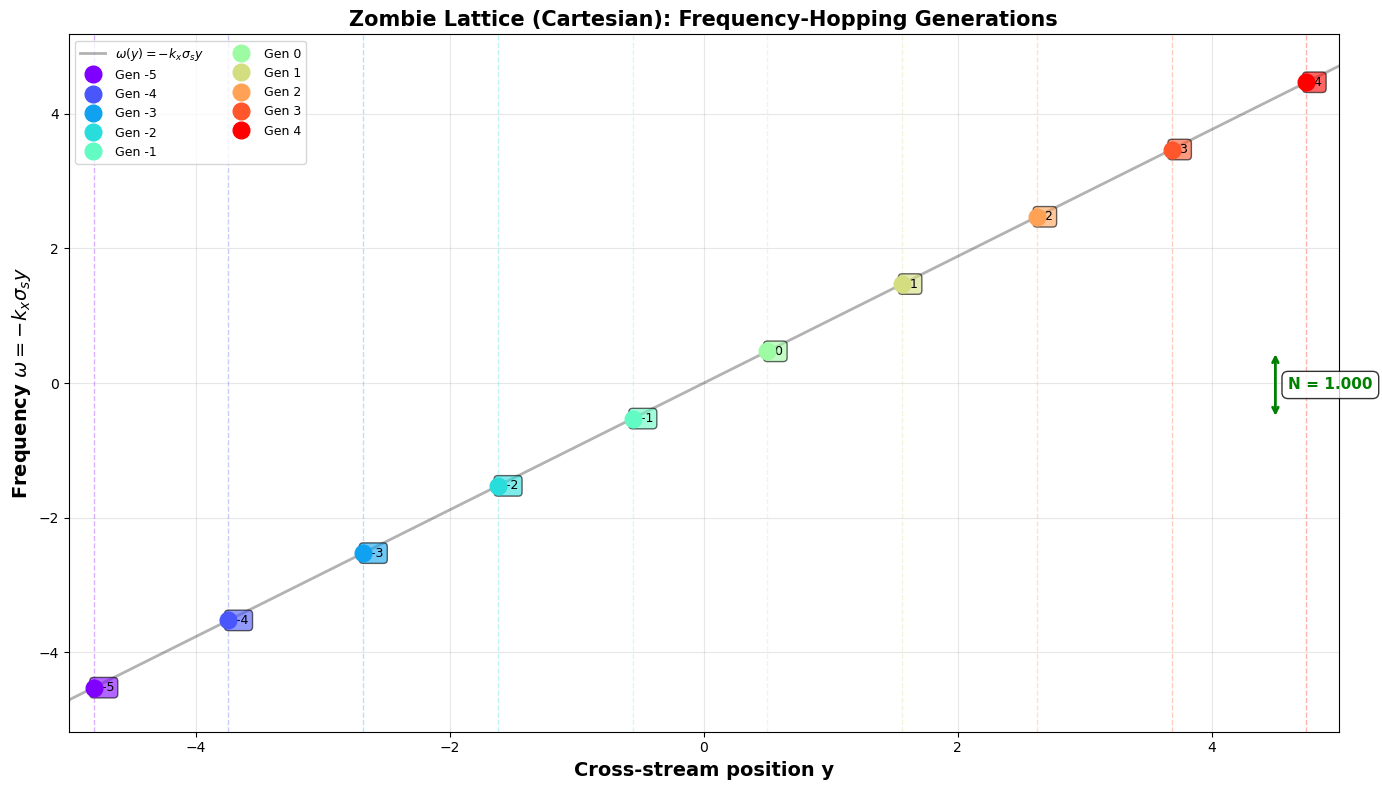

In [8]:
def calculate_zombie_lattice_cartesian(kx, sigma_s, N, y_start, y_min=-50.0, y_max=50.0):
    """
    Calculate zombie lattice for Cartesian shear flow.
    
    Resonance condition: |kx*sigma_s*y_i - kx*sigma_s*y_{i+1}| = N
    Simplifies to: |kx*sigma_s| * |y_i - y_{i+1}| = N
    Therefore: y_{i+1} = y_i ± N/(|kx*sigma_s|)
    
    Parameters:
    -----------
    kx : float
        Streamwise wavenumber
    sigma_s : float
        Shear rate
    N : float
        Brunt-Väisälä frequency
    y_start : float
        Starting y position (generation 0)
    y_min, y_max : float
        Domain boundaries
    
    Returns:
    --------
    lattice : dict
        Dictionary with 'y_positions', 'generations', 'frequencies'
    """
    
    # Frequency jump between generations
    delta_y = N / abs(kx * sigma_s)
    
    print(f"\n{'='*70}")
    print(f"ZOMBIE LATTICE CALCULATION (CARTESIAN)")
    print(f"{'='*70}")
    print(f"  kx = {kx:.6f}, σs = {sigma_s:.6f}, N = {N:.6f}")
    print(f"  Frequency spacing: Δy = N/(|kx·σs|) = {delta_y:.6f}")
    
    # Starting frequency
    omega_0 = -kx * sigma_s * y_start
    
    print(f"  Starting at y0 = {y_start:.6f}, ω0 = {omega_0:.6f}")
    
    # Generate lattice in both directions
    generations = [0]
    y_positions = [y_start]
    
    # Positive y direction
    y_current = y_start
    gen = 0
    while True:
        gen += 1
        y_next = y_current + delta_y
        if y_next > y_max:
            break
        y_positions.append(y_next)
        generations.append(gen)
        y_current = y_next
    
    # Negative y direction
    y_current = y_start
    gen = 0
    while True:
        gen -= 1
        y_next = y_current - delta_y
        if y_next < y_min:
            break
        y_positions.insert(0, y_next)
        generations.insert(0, gen)
        y_current = y_next
    
    # Calculate frequencies
    frequencies = [-kx * sigma_s * y for y in y_positions]
    
    print(f"\n  Total generations: {len(generations)}")
    print(f"  Generation range: [{min(generations)}, {max(generations)}]")
    print(f"  Y range: [{min(y_positions):.4f}, {max(y_positions):.4f}]")
    
    # Verify spacing
    if len(y_positions) > 1:
        spacings = np.diff(y_positions)
        print(f"  Y-spacing: mean={np.mean(spacings):.6f}, std={np.std(spacings):.8f}")
        
        freq_diffs = np.abs(np.diff(frequencies))
        print(f"  Frequency jumps: mean={np.mean(freq_diffs):.6f}, target N={N:.6f}")
    
    return {
        'y_positions': y_positions,
        'generations': generations,
        'frequencies': frequencies,
        'delta_y': delta_y
    }


# Set parameters
m = 1.0  # mode number
kx = 2.0 * np.pi / Lx * m  # streamwise wavenumber
sigma_s = -1.5  # shear rate (cyclonic)
N = 1.0  # Brunt-Väisälä frequency

# Calculate zombie lattice
y_start_zombie = 0.5  # Start at y = 0.5
y_min_zombie = -5.0
y_max_zombie = 5.0

zombie_lattice_cart = calculate_zombie_lattice_cartesian(
    kx, sigma_s, N, y_start_zombie,
    y_min=y_min_zombie, y_max=y_max_zombie
)

# Visualize lattice
fig, ax = plt.subplots(1, 1, figsize=(14, 8))

# Plot background frequency profile
y_profile = np.linspace(y_min_zombie, y_max_zombie, 1000)
omega_profile = -kx * sigma_s * y_profile
ax.plot(y_profile, omega_profile, 'k-', linewidth=2, alpha=0.3, label='$\\omega(y) = -k_x \\sigma_s y$')

# Color map for generations
n_gen = len(zombie_lattice_cart['generations'])
colors = plt.cm.rainbow(np.linspace(0, 1, n_gen))

# Plot each generation
for i, (gen, y_pos, freq) in enumerate(zip(zombie_lattice_cart['generations'],
                                            zombie_lattice_cart['y_positions'],
                                            zombie_lattice_cart['frequencies'])):
    ax.plot(y_pos, freq, 'o', color=colors[i], markersize=12, label=f'Gen {gen}', zorder=5)
    ax.axvline(y_pos, color=colors[i], linestyle='--', linewidth=1, alpha=0.3)
    ax.text(y_pos, freq, f'  {gen}', fontsize=9, va='center', ha='left',
           bbox=dict(boxstyle='round,pad=0.3', facecolor=colors[i], alpha=0.6))

# Mark N spacing
freq_0 = zombie_lattice_cart['frequencies'][zombie_lattice_cart['generations'].index(0)]
ax.annotate('', xy=(y_max_zombie*0.9, freq_0), xytext=(y_max_zombie*0.9, freq_0 - N),
           arrowprops=dict(arrowstyle='<->', color='green', lw=2))
ax.text(y_max_zombie*0.92, freq_0 - N/2, f'N = {N:.3f}', fontsize=11,
       va='center', ha='left', color='green', fontweight='bold',
       bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8))

ax.set_xlabel('Cross-stream position y', fontsize=14, fontweight='bold')
ax.set_ylabel('Frequency $\\omega = -k_x \\sigma_s y$', fontsize=14, fontweight='bold')
ax.set_title(f'Zombie Lattice (Cartesian): Frequency-Hopping Generations', fontsize=15, fontweight='bold')
ax.legend(fontsize=9, ncol=2, loc='best')
ax.grid(True, alpha=0.3)
ax.set_xlim(y_min_zombie, y_max_zombie)

plt.tight_layout()
plt.show()

## 6. Memory-Resetting Ray Tracing

Trace rays between zombie lattice generations with frequency reset at each critical layer.

In [9]:
def trace_zombie_chain_cartesian(N, f, sigma_s, kx, kz, Lx, zombie_lattice, z_start=0.0, dy=0.01, max_generations=None):
    """
    Perform memory-resetting ray tracing for zombie chain reaction in Cartesian coordinates.
    
    Algorithm:
    1. Start at generation 0 with z=z_start, trace BOTH sign choices (±ky/kz)
    2. From each arrival point, trace to neighboring generations with BOTH signs
    3. Reset frequency at each generation: omega_i = -kx*sigma_s*y_i
    4. Track multiple (y,z) arrival points at each generation
    
    Parameters:
    -----------
    N, f, sigma_s : float
        Flow parameters
    kx, kz : float
        Fixed wavenumbers
    Lx : float
        Domain size
    zombie_lattice : dict
        Lattice information
    z_start : float
        Initial z at generation 0
    dy : float
        Integration step
    max_generations : int or None
        Maximum number of generation levels to trace (None = trace all)
    
    Returns:
    --------
    segments : list of dict
        Ray segments between generations, each with sign_choice info
    """
    
    segments = []
    
    y_positions = zombie_lattice['y_positions']
    generations = zombie_lattice['generations']
    frequencies = zombie_lattice['frequencies']
    
    # Mapping from generation to index
    gen_to_idx = {gen: idx for idx, gen in enumerate(generations)}
    
    # Track multiple (y,z) points at each generation
    # Structure: {gen: [(z_value, parent_gen, parent_z, sign_used), ...]}
    points_at_generation = {0: [(z_start, None, None, None)]}
    
    # Track traced segments to avoid duplicates
    # Key: (gen_from, gen_to, z_from, sign_choice)
    traced_segments = set()
    
    def trace_segment(gen_from, gen_to, z_from, sign_choice):
        """Trace from (gen_from, z_from) to gen_to with given sign_choice"""
        # Check if already traced
        segment_key = (gen_from, gen_to, z_from, sign_choice)
        if segment_key in traced_segments:
            return None
        
        if gen_from not in gen_to_idx or gen_to not in gen_to_idx:
            return None
        
        idx_from = gen_to_idx[gen_from]
        idx_to = gen_to_idx[gen_to]
        
        y_from = y_positions[idx_from]
        y_to = y_positions[idx_to]
        omega_from = frequencies[idx_from]
        
        sign_str = "+" if sign_choice > 0 else "-"
        print(f"\n  Gen {gen_from:3d} → {gen_to:3d} (sign={sign_str}): y=[{y_from:.4f} → {y_to:.4f}]")
        print(f"    Starting: z={z_from:.4f}, ω={omega_from:.6f}")
        
        try:
            # Create tracer with frequency for this generation
            # omega_from = -kx*sigma_s*y_from for memory-resetting physics
            
            tracer_seg = CartesianShearingBoxRays(N, f, sigma_s, kx, Lx, omega=omega_from)
            
            # Trace from y_from to y_to
            y_seg_list = []
            z_seg_list = []
            y_current = y_from
            z_current = z_from
            
            # Determine step direction
            dy_step = dy if y_to > y_from else -dy
            n_steps = int(abs(y_to - y_from) / dy)
            
            for step in range(n_steps + 1):
                y_seg_list.append(y_current)
                z_seg_list.append(z_current)
                
                if step < n_steps:
                    dzdy = tracer_seg.compute_dzdy(y_current, kz, sign_choice)
                    if dzdy is None:
                        break
                    
                    z_current += dzdy * dy_step
                    y_current += dy_step
            
            y_seg = np.array(y_seg_list)
            z_seg = np.array(z_seg_list)
            
            if len(y_seg) > 0:
                # Find z at destination
                idx_closest = np.argmin(np.abs(y_seg - y_to))
                z_to = z_seg[idx_closest]
                
                # Store arrival point at destination
                if gen_to not in points_at_generation:
                    points_at_generation[gen_to] = []
                points_at_generation[gen_to].append((z_to, gen_from, z_from, sign_choice))
                
                print(f"    Arriving: z={z_to:.4f} (traced {len(y_seg)} points)")
                print(f"    Gen {gen_to} now has {len(points_at_generation[gen_to])} arrival point(s)")
                
                segment_data = {
                    'y': y_seg,
                    'z': z_seg,
                    'omega': omega_from,
                    'gen_from': gen_from,
                    'gen_to': gen_to,
                    'y_from': y_from,
                    'y_to': y_to,
                    'z_from': z_from,
                    'z_to': z_to,
                    'sign_choice': sign_choice
                }
                
                traced_segments.add(segment_key)
                return segment_data
            else:
                print(f"    ERROR: No points traced")
                return None
        
        except Exception as e:
            print(f"    ERROR: {e}")
            return None
    
    print(f"\n{'='*70}")
    print(f"BRANCHING RAY TRACE (CARTESIAN) - BOTH BRANCHES")
    print(f"{'='*70}")
    print(f"Starting at generation 0, y={y_positions[gen_to_idx[0]]:.4f}, z={z_start:.4f}")
    if max_generations:
        print(f"Tracing up to {max_generations} generation levels")
    
    # Level-by-level branching with both sign choices
    current_level = [0]
    visited = set([0])
    
    level = 0
    
    while current_level:
        if max_generations is not None and level >= max_generations:
            print(f"\nReached maximum generation level {max_generations}, stopping")
            break
        
        next_level = set()
        level += 1
        
        print(f"\n{'='*70}")
        print(f"LEVEL {level}: Processing generations {current_level}")
        print(f"{'='*70}")
        
        for gen_current in current_level:
            print(f"\n--- Processing generation {gen_current} ---")
            
            # Get all arrival points at this generation
            if gen_current not in points_at_generation:
                print(f"  Warning: No points at generation {gen_current}, skipping")
                continue
            
            arrival_points = points_at_generation[gen_current]
            print(f"  Generation {gen_current} has {len(arrival_points)} arrival point(s)")
            
            # From each arrival point, trace to neighbors with BOTH sign choices
            for z_current, parent_gen, parent_z, parent_sign in arrival_points:
                print(f"  From z={z_current:.4f}")
                
                # Trace to neighboring generations
                for gen_neighbor in [gen_current - 1, gen_current + 1]:
                    if gen_neighbor not in gen_to_idx:
                        continue
                    
                    # Trace with BOTH sign choices
                    for sign in [+1, -1]:
                        segment = trace_segment(gen_current, gen_neighbor, z_current, sign)
                        if segment is not None:
                            segments.append(segment)
                            next_level.add(gen_neighbor)
        
        current_level = sorted(list(next_level))
        visited.update(current_level)
    
    print(f"\n{'='*70}")
    print(f"Successfully traced {len(segments)} segments")
    print(f"{'='*70}")
    
    return segments


# Perform zombie chain reaction tracing
print("\n" + "="*70)
print("TRACING ZOMBIE CHAIN REACTION (CARTESIAN)")
print("="*70)

if len(zombie_lattice_cart['generations']) < 2:
    print("ERROR: Need at least 2 generations")
else:
    # Trace with both branches, limit to first few generations
    zombie_segments_cart = trace_zombie_chain_cartesian(
        N, f, sigma_s, kx, kz, Lx,
        zombie_lattice_cart,
        z_start=0.0,
        dy=0.01,
        max_generations=3  # Limit to 3 generation levels for clarity
    )
    
    print(f"\n{'='*70}")
    print(f"TRACING COMPLETE")
    print(f"{'='*70}")
    print(f"Total segments traced: {len(zombie_segments_cart)}")


TRACING ZOMBIE CHAIN REACTION (CARTESIAN)

BRANCHING RAY TRACE (CARTESIAN) - BOTH BRANCHES
Starting at generation 0, y=0.5000, z=0.0000
Tracing up to 3 generation levels

LEVEL 1: Processing generations [0]

--- Processing generation 0 ---
  Generation 0 has 1 arrival point(s)
  From z=0.0000

  Gen   0 →  -1 (sign=+): y=[0.5000 → -0.5610]
    Starting: z=0.0000, ω=0.471239
Shearing Box Ray Tracer Initialized:
  N = 1.0, f = 1.0, σ_s = -1.5
  F = f(σ_s + f) = -0.5
  kx = 0.6283185307179586 (fixed)
  Critical layers at y = ±1.0610
  No evanescent region (F = -0.5 <= 0)
    Arriving: z=-1.5007 (traced 107 points)
    Gen -1 now has 1 arrival point(s)

  Gen   0 →  -1 (sign=-): y=[0.5000 → -0.5610]
    Starting: z=0.0000, ω=0.471239
Shearing Box Ray Tracer Initialized:
  N = 1.0, f = 1.0, σ_s = -1.5
  F = f(σ_s + f) = -0.5
  kx = 0.6283185307179586 (fixed)
  Critical layers at y = ±1.0610
  No evanescent region (F = -0.5 <= 0)
    Arriving: z=1.5007 (traced 107 points)
    Gen -1 now has

## 7. Visualize Zombie Chain Reaction

Plot the branching ray paths with frequency resets at each generation.

Maximum tracing step: 3
Total unique arrival points: 25


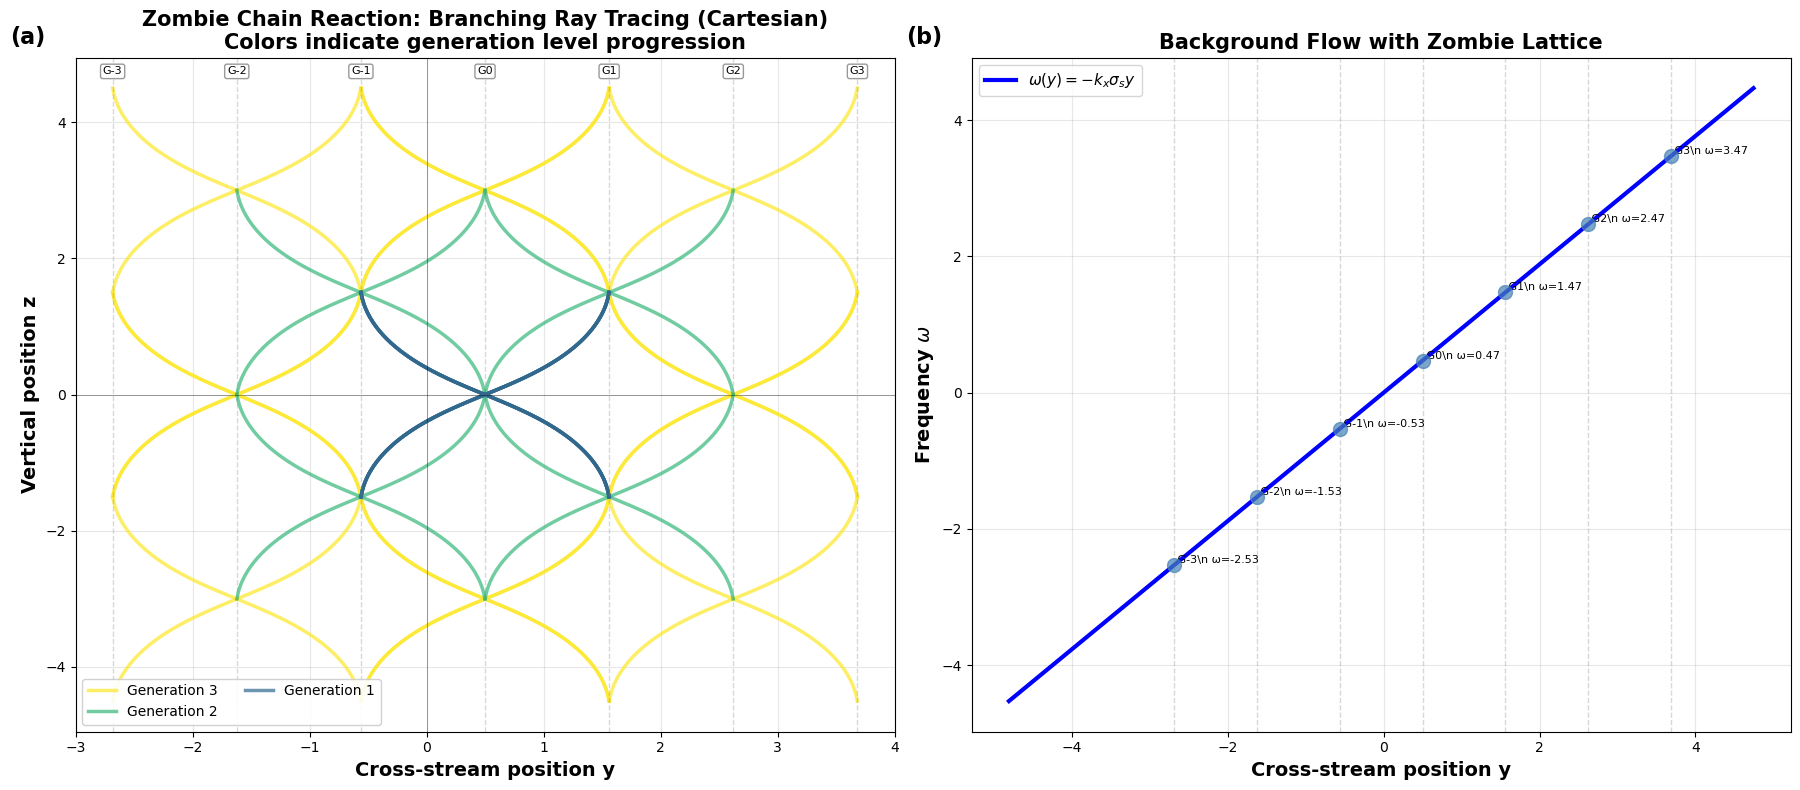


ZOMBIE CHAIN REACTION SUMMARY (CARTESIAN)
Number of segments traced: 84
Zombie lattice layers: 10
Y range: [-4.8052, 4.7441]
Frequency spacing: ΔN = 1.0000


In [10]:
if len(zombie_segments_cart) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    
    # Build a tracing step map by reconstructing the branching tree
    # Key insight: we need to track WHEN each segment was traced, not which generation it connects
    
    # First pass: identify all unique (gen, z) points and assign tracing steps
    # Start from gen 0, z_start as step 0
    point_to_step = {(0, 0.0): 0}  # (gen, z) -> step
    max_step = 0
    
    # Process segments in groups by their "distance" from origin
    # We'll use a simple heuristic: segments are traced level-by-level
    segments_with_step = []
    
    for seg in zombie_segments_cart:
        gen_from = seg['gen_from']
        gen_to = seg['gen_to']
        z_from = seg['z_from']
        z_to = seg['z_to']
        
        # Round z to avoid floating point comparison issues
        z_from_key = round(z_from, 6)
        z_to_key = round(z_to, 6)
        
        # Get step of starting point
        start_key = (gen_from, z_from_key)
        if start_key in point_to_step:
            step_from = point_to_step[start_key]
        else:
            # Find closest match (in case of small numerical differences)
            step_from = 0
            for (g, z), s in point_to_step.items():
                if g == gen_from and abs(z - z_from_key) < 0.01:
                    step_from = s
                    break
        
        # This segment represents step_from -> step_from+1
        step_to = step_from + 1
        max_step = max(max_step, step_to)
        
        # Record arrival point
        end_key = (gen_to, z_to_key)
        if end_key not in point_to_step:
            point_to_step[end_key] = step_to
        
        segments_with_step.append({
            **seg,
            'step': step_to  # The step at which this segment was traced
        })
    
    print(f"Maximum tracing step: {max_step}")
    print(f"Total unique arrival points: {len(point_to_step)}")
    
    # Create colormap for generation levels
    cmap = plt.cm.viridis
    norm = plt.Normalize(vmin=0, vmax=max_step)
    
    # Left panel: Ray paths
    ax1 = axes[0]
    
    # Add subplot label (a)
    ax1.text(-0.08, 1.02, '(a)', transform=ax1.transAxes, fontsize=16, fontweight='bold')
    
    # Group segments by step for plotting order (later steps in background)
    segments_by_step = {}
    for seg in segments_with_step:
        step = seg['step']
        if step not in segments_by_step:
            segments_by_step[step] = []
        segments_by_step[step].append(seg)
    
    # Track which steps we've plotted for legend
    plotted_steps = set()
    
    # Plot from highest step to lowest (background to foreground)
    for step in sorted(segments_by_step.keys(), reverse=True):
        step_color = cmap(norm(step))
        
        for seg in segments_by_step[step]:
            # Add label only once per step
            label = f'Generation {step}' if step not in plotted_steps else None
            if label:
                plotted_steps.add(step)
            
            # Plot colored line
            ax1.plot(seg['y'], seg['z'], '-', color=step_color, 
                    linewidth=2.5, alpha=0.7, zorder=2, label=label)
    
    # Mark zombie lattice layers (generation y-positions)
    gen_to_idx_local = {gen: idx for idx, gen in enumerate(zombie_lattice_cart['generations'])}
    traced_gens = set()
    for seg in zombie_segments_cart:
        traced_gens.add(seg['gen_from'])
        traced_gens.add(seg['gen_to'])
    
    for gen in sorted(traced_gens):
        if gen in gen_to_idx_local:
            idx = gen_to_idx_local[gen]
            y_layer = zombie_lattice_cart['y_positions'][idx]
            
            ax1.axvline(y_layer, color='gray', linestyle='--', linewidth=1, alpha=0.3)
            ax1.text(y_layer, ax1.get_ylim()[1]*0.95, f'G{gen}', fontsize=8, ha='center',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='gray', alpha=0.8))
    
    ax1.set_xlabel('Cross-stream position y', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Vertical position z', fontsize=14, fontweight='bold')
    ax1.set_title('Zombie Chain Reaction: Branching Ray Tracing (Cartesian)\n'
                 'Colors indicate generation level progression', 
                 fontsize=15, fontweight='bold')
    ax1.legend(fontsize=10, loc='best', framealpha=0.9, ncol=2)
    ax1.grid(True, alpha=0.3)
    ax1.axhline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.5)
    ax1.axvline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.5)
    
    # Right panel: Frequency profile with zombie lattice
    ax2 = axes[1]
    
    # Add subplot label (b)
    ax2.text(-0.08, 1.02, '(b)', transform=ax2.transAxes, fontsize=16, fontweight='bold')
    
    y_profile = np.linspace(min(zombie_lattice_cart['y_positions']), 
                           max(zombie_lattice_cart['y_positions']), 500)
    omega_profile = -kx * sigma_s * y_profile
    ax2.plot(y_profile, omega_profile, 'b-', linewidth=3, label='$\\omega(y) = -k_x \\sigma_s y$')
    
    # Mark zombie lattice layers that were actually traced
    gen_to_idx_local2 = {gen: idx for idx, gen in enumerate(zombie_lattice_cart['generations'])}
    for gen in sorted(traced_gens):
        if gen in gen_to_idx_local2:
            idx = gen_to_idx_local2[gen]
            y_layer = zombie_lattice_cart['y_positions'][idx]
            omega_layer = zombie_lattice_cart['frequencies'][idx]
            
            ax2.plot(y_layer, omega_layer, 'o', color='steelblue', markersize=10, 
                    alpha=0.7, zorder=5)
            ax2.axvline(y_layer, color='gray', linestyle='--', linewidth=1, alpha=0.3)
            
            ax2.text(y_layer, omega_layer, f' G{gen}\\n ω={omega_layer:.2f}',
                    fontsize=8, va='bottom', ha='left')
    
    ax2.set_xlabel('Cross-stream position y', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Frequency $\\omega$', fontsize=14, fontweight='bold')
    ax2.set_title('Background Flow with Zombie Lattice', fontsize=15, fontweight='bold')
    ax2.legend(fontsize=11, loc='best')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Summary
    print(f"\n{'='*70}")
    print(f"ZOMBIE CHAIN REACTION SUMMARY (CARTESIAN)")
    print(f"{'='*70}")
    print(f"Number of segments traced: {len(zombie_segments_cart)}")
    print(f"Zombie lattice layers: {len(zombie_lattice_cart['generations'])}")
    print(f"Y range: [{min(zombie_lattice_cart['y_positions']):.4f}, "
          f"{max(zombie_lattice_cart['y_positions']):.4f}]")
    print(f"Frequency spacing: ΔN = {N:.4f}")
    
else:
    print("No segments to plot - check if zombie lattice calculation succeeded")